# ElderGuard Analytics - Week 6 EDA + Insights

This notebook is for **Week 6 only**. It performs Exploratory Data Analysis (EDA) on the smart home gas monitoring dataset.

Week 7 model training and tuning are done separately in the `.py` pipeline inside the `src/` folder.

## 1. Import Libraries

Purpose: Load the Python libraries needed for database access, data analysis, and visualisation.

In [1]:
import json
import sqlite3
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

# Create output folders for Week 6 EDA
Path("results").mkdir(exist_ok=True)
Path("visuals").mkdir(exist_ok=True)

## 2. Load External Configuration

Purpose: Use `config.json` instead of hardcoding file paths and column names directly in the notebook.

In [2]:
with open("config.json", "r", encoding="utf-8") as file:
    config = json.load(file)

db_path = config["database"]["path"]
table_name = config["database"]["table_name"]
target_column = config["columns"]["target"]
drop_columns = config["columns"].get("drop_columns", [])

print("Database path:", db_path)
print("Table name:", table_name)
print("Target column:", target_column)
print("Columns planned to drop later:", drop_columns)

Database path: data/gas_monitoring.db
Table name: gas_monitoring
Target column: Activity Level
Columns planned to drop later: ['Session ID']


## 3. Inspect SQLite Database

Purpose: Confirm that the SQLite database can be accessed and identify the available table names before loading the dataset.

In [3]:
connection = sqlite3.connect(db_path)

tables = pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table';", connection)
display(tables)

,name
0,gas_monitoring


## 4. Load Dataset

Purpose: Load the `gas_monitoring` table into a pandas DataFrame for EDA.

In [4]:
df = pd.read_sql_query(f"SELECT * FROM {table_name}", connection)
connection.close()

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (10000, 14)


,Time of Day,Temperature,Humidity,CO2_InfraredSensor,CO2_ElectroChemicalSensor,MetalOxideSensor_Unit1,MetalOxideSensor_Unit2,MetalOxideSensor_Unit3,MetalOxideSensor_Unit4,CO_GasSensor,Session ID,HVAC Operation Mode,Ambient Light Level,Activity Level
0,morning,19.63,53.83,125.486389,571.089440,478.554958,735.850412,654.625253,565.051969,2.0,7241,off,very_dim,Low Activity
1,morning,292.81,53.69,126.343018,575.789501,491.955151,740.282738,655.734327,557.078486,1.0,7241,ventilation_only,bright,Low Activity
2,morning,19.62,54.25,126.560695,585.543111,505.560808,737.112906,649.962421,558.065196,1.0,7241,eco_mode,None,Low Activity
3,morning,20.10,50.48,113.504877,597.449961,515.142272,744.020651,676.150075,600.222210,NaN,7241,eco_mode,very_bright,High Activity
4,morning,19.89,48.42,92.766225,613.654875,535.664558,770.265441,720.274019,625.731124,1.0,7241,heating_active,moderate,LowActivity


## 5. Dataset Structure

Purpose: Understand the number of rows/columns, column names, and data types. This helps us decide which features are numerical and which are categorical.

In [5]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

structure = pd.DataFrame({
    "column": df.columns,
    "data_type": df.dtypes.astype(str),
    "non_null_count": df.notna().sum().values,
    "missing_count": df.isna().sum().values
})

display(structure)
structure.to_csv("results/column_structure.csv", index=False)

Rows: 10000
Columns: 14


,column,data_type,non_null_count,missing_count
Time of Day,Time of Day,object,10000,0
Temperature,Temperature,float64,10000,0
Humidity,Humidity,float64,8072,1928
CO2_InfraredSensor,CO2_InfraredSensor,float64,10000,0
CO2_ElectroChemicalSensor,CO2_ElectroChemicalSensor,float64,10000,0
MetalOxideSensor_Unit1,MetalOxideSensor_Unit1,float64,10000,0
MetalOxideSensor_Unit2,MetalOxideSensor_Unit2,float64,8590,1410
MetalOxideSensor_Unit3,MetalOxideSensor_Unit3,float64,10000,0
MetalOxideSensor_Unit4,MetalOxideSensor_Unit4,float64,10000,0
CO_GasSensor,CO_GasSensor,float64,9166,834


## 6. Missing Values Check

Purpose: Identify missing data before modelling. Missing values must be handled later during preprocessing.

,column,missing_count,missing_percentage
2,Humidity,1928,19.28
6,MetalOxideSensor_Unit2,1410,14.10
12,Ambient Light Level,1054,10.54
9,CO_GasSensor,834,8.34
0,Time of Day,0,0.00
1,Temperature,0,0.00
3,CO2_InfraredSensor,0,0.00
4,CO2_ElectroChemicalSensor,0,0.00
5,MetalOxideSensor_Unit1,0,0.00
7,MetalOxideSensor_Unit3,0,0.00


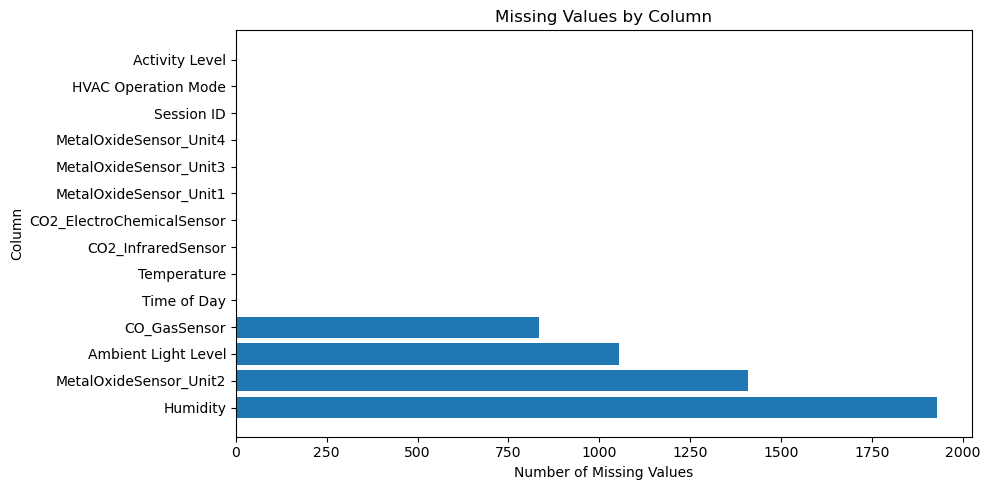

In [6]:
missing_values = df.isna().sum().reset_index()
missing_values.columns = ["column", "missing_count"]
missing_values["missing_percentage"] = (missing_values["missing_count"] / len(df) * 100).round(2)
missing_values = missing_values.sort_values("missing_count", ascending=False)

display(missing_values)
missing_values.to_csv("results/missing_values.csv", index=False)

plt.figure(figsize=(10, 5))
plt.barh(missing_values["column"].astype(str), missing_values["missing_count"])
plt.title("Missing Values by Column")
plt.xlabel("Number of Missing Values")
plt.ylabel("Column")
plt.tight_layout()
plt.savefig("visuals/missing_values.png", dpi=150)
plt.show()

### Insight: Missing Values

Columns with missing values must not be ignored. For Week 7, numerical missing values can be filled with the median, while categorical missing values can be filled using the most frequent value. This is safer than deleting many rows.

## 7. Duplicate Rows Check

Purpose: Check if duplicate records exist, because duplicates can bias model training if left untreated.

In [7]:
duplicate_count = df.duplicated().sum()
print("Duplicate rows:", duplicate_count)

duplicate_summary = pd.DataFrame({"duplicate_rows": [duplicate_count]})
duplicate_summary.to_csv("results/duplicate_summary.csv", index=False)

Duplicate rows: 171


## 8. Clean Target Labels for EDA

Purpose: The target column may contain inconsistent labels such as `LowActivity` and `Low Activity`. We standardise them before analysing class distribution.

In [8]:
def normalise_activity_label(value):
    if pd.isna(value):
        return value
    cleaned = str(value).strip().replace("_", " ")
    replacements = {
        "LowActivity": "Low Activity",
        "ModerateActivity": "Moderate Activity",
        "HighActivity": "High Activity",
        "Lowactivity": "Low Activity",
        "Moderateactivity": "Moderate Activity",
        "Highactivity": "High Activity",
    }
    cleaned = replacements.get(cleaned, cleaned)
    cleaned = " ".join(cleaned.split())
    return cleaned.title()

df_eda = df.copy()
df_eda[target_column] = df_eda[target_column].apply(normalise_activity_label)

print("Original labels:")
print(df[target_column].value_counts(dropna=False))

print("\nCleaned labels:")
print(df_eda[target_column].value_counts(dropna=False))

Original labels:
Low Activity         5244
Moderate Activity    2812
High Activity        1095
ModerateActivity      326
Low_Activity          285
LowActivity           238
Name: Activity Level, dtype: int64

Cleaned labels:
Low Activity         5767
Moderate Activity    3138
High Activity        1095
Name: Activity Level, dtype: int64


## 9. Activity Level Distribution

Purpose: Understand whether the target classes are balanced. Class imbalance affects model choice and metric selection later.

,Activity Level,count,percentage
0,Low Activity,5767,57.67
1,Moderate Activity,3138,31.38
2,High Activity,1095,10.95


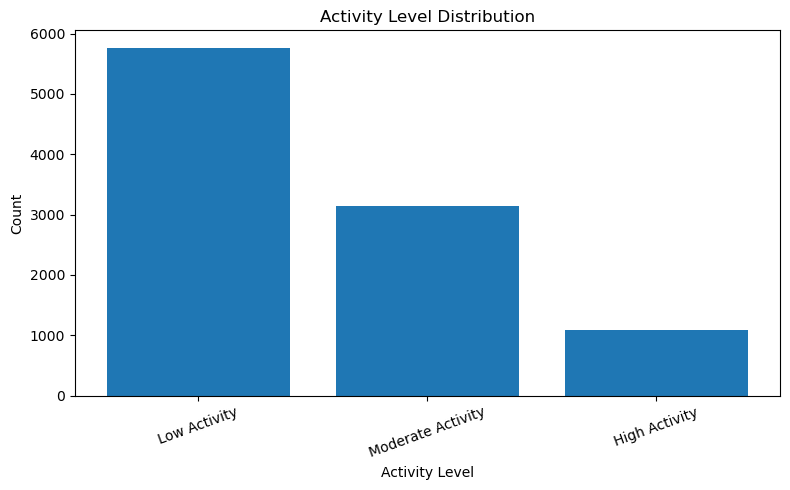

In [9]:
class_distribution = df_eda[target_column].value_counts(dropna=False).reset_index()
class_distribution.columns = [target_column, "count"]
class_distribution["percentage"] = (class_distribution["count"] / len(df_eda) * 100).round(2)

display(class_distribution)
class_distribution.to_csv("results/class_distribution.csv", index=False)

plt.figure(figsize=(8, 5))
plt.bar(class_distribution[target_column].astype(str), class_distribution["count"])
plt.title("Activity Level Distribution")
plt.xlabel("Activity Level")
plt.ylabel("Count")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("visuals/activity_level_distribution.png", dpi=150)
plt.show()

### Insight: Activity Level Distribution

If one activity level appears much more than the others, accuracy alone may be misleading. In Week 7, Macro F1 should be considered because it treats each class more equally.

## 10. Numerical Feature Summary

Purpose: Examine minimum, maximum, mean, median, and spread of numerical sensor readings. This helps identify unrealistic values or outliers.

In [10]:
numeric_columns = df_eda.select_dtypes(include=[np.number]).columns.tolist()
categorical_columns = df_eda.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numerical columns:", numeric_columns)
print("Categorical columns:", categorical_columns)

numerical_summary = df_eda[numeric_columns].describe().T
display(numerical_summary)
numerical_summary.to_csv("results/numerical_summary.csv")

Numerical columns: ['Temperature', 'Humidity', 'CO2_InfraredSensor', 'CO2_ElectroChemicalSensor', 'MetalOxideSensor_Unit1', 'MetalOxideSensor_Unit2', 'MetalOxideSensor_Unit3', 'MetalOxideSensor_Unit4', 'CO_GasSensor', 'Session ID']
Categorical columns: ['Time of Day', 'HVAC Operation Mode', 'Ambient Light Level', 'Activity Level']


,count,mean,std,min,25%,50%,75%,max
Temperature,10000.0,42.243124,73.974956,6.903485,18.937500,20.510000,23.172500,307.070000
Humidity,8072.0,51.643609,21.333894,-49.870000,47.660000,51.390000,53.840000,198.900000
CO2_InfraredSensor,10000.0,109.864352,33.793851,-17.472184,96.660377,112.807103,124.540226,237.873938
CO2_ElectroChemicalSensor,10000.0,578.634082,22.573537,408.599386,559.353100,579.361082,595.569759,637.895790
MetalOxideSensor_Unit1,10000.0,470.932316,51.459025,286.825662,440.035413,469.146955,494.770045,632.891693
MetalOxideSensor_Unit2,8590.0,728.354408,29.140123,611.168916,709.660122,726.748925,744.879789,807.732943
MetalOxideSensor_Unit3,10000.0,680.488646,55.953530,456.673900,658.519775,679.908353,703.522845,906.213097
MetalOxideSensor_Unit4,10000.0,612.247715,43.174354,412.791904,585.511731,609.526245,636.012105,736.112361
CO_GasSensor,9166.0,1.288239,0.779754,0.000000,1.000000,1.000000,2.000000,4.000000
Session ID,10000.0,5427.921400,2590.836924,1374.000000,3074.000000,5214.000000,7395.000000,9658.000000


## 11. Boxplots for Outlier Checking

Purpose: Visualise possible outliers in numerical columns. The problem statement warns that data may be synthetic or contaminated, so this step is important before training.

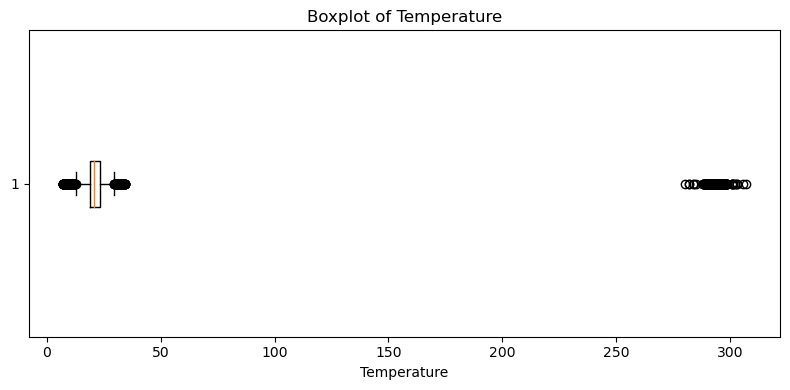

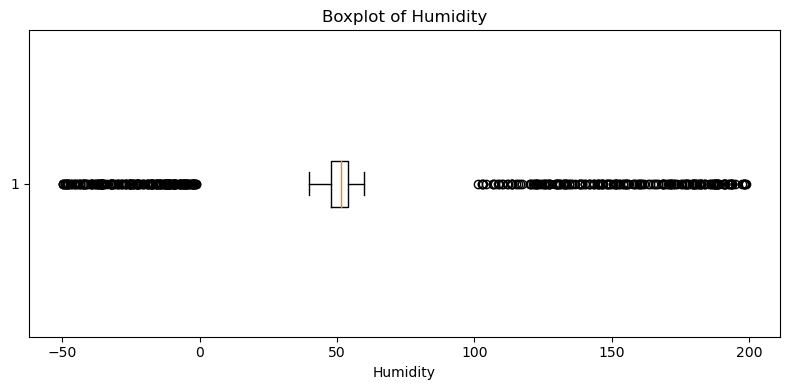

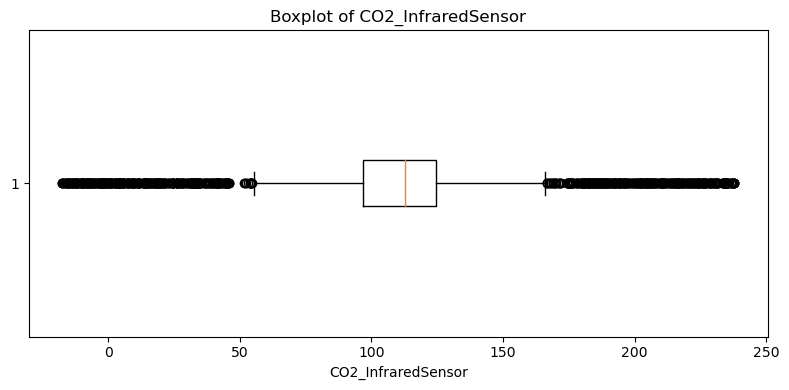

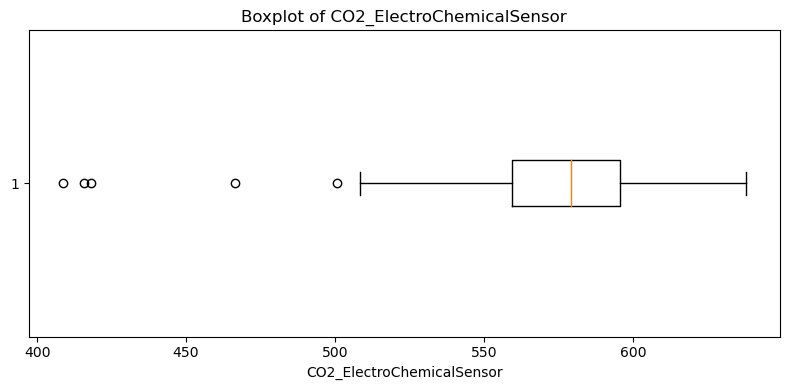

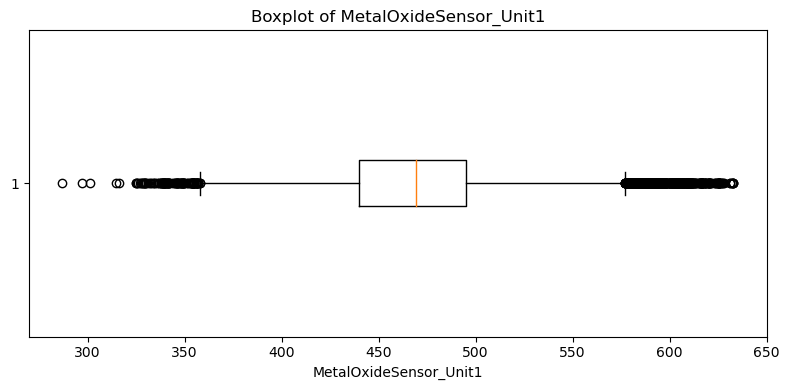

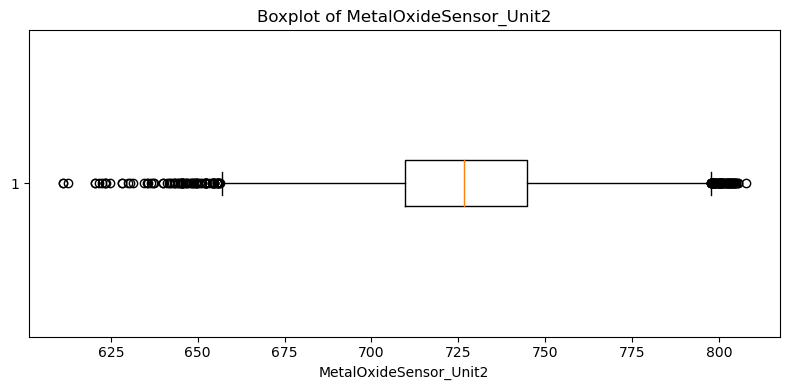

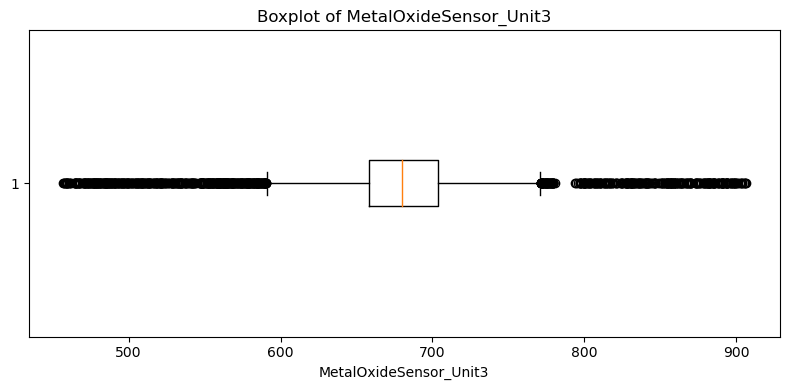

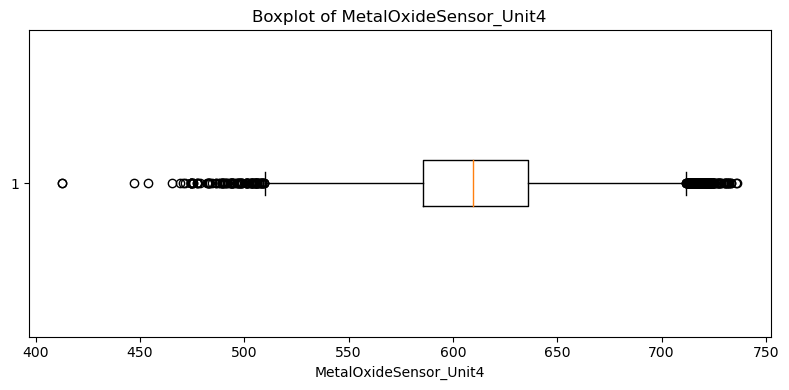

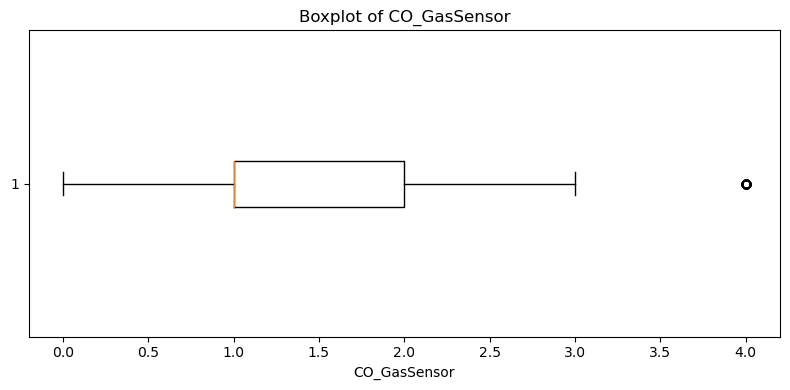

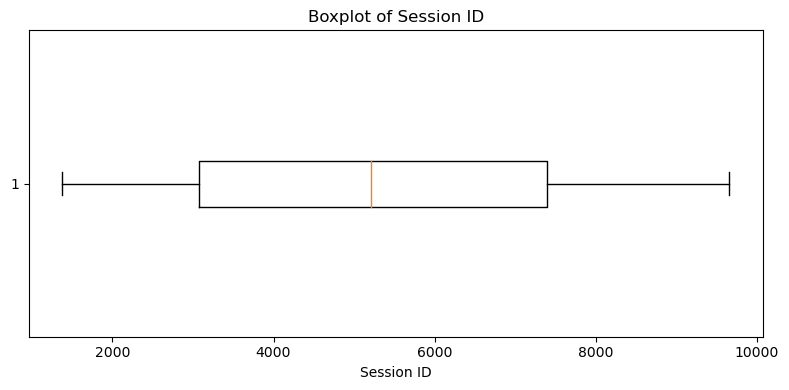

In [11]:
for column in numeric_columns:
    plt.figure(figsize=(8, 4))
    plt.boxplot(df_eda[column].dropna(), vert=False)
    plt.title(f"Boxplot of {column}")
    plt.xlabel(column)
    plt.tight_layout()
    plt.savefig(f"visuals/boxplot_{column.replace(' ', '_')}.png", dpi=150)
    plt.show()

## 12. IQR Outlier Count

Purpose: Count possible outliers using the IQR rule. This is not deleting data yet; it only documents data quality concerns.

In [12]:
outlier_rows = []
iqr_multiplier = config.get("eda", {}).get("iqr_multiplier", 1.5)

for column in numeric_columns:
    q1 = df_eda[column].quantile(0.25)
    q3 = df_eda[column].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - iqr_multiplier * iqr
    upper_bound = q3 + iqr_multiplier * iqr
    outlier_count = ((df_eda[column] < lower_bound) | (df_eda[column] > upper_bound)).sum()
    outlier_rows.append({
        "column": column,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "outlier_count": int(outlier_count),
        "outlier_percentage": round(outlier_count / len(df_eda) * 100, 2)
    })

outlier_summary = pd.DataFrame(outlier_rows).sort_values("outlier_count", ascending=False)
display(outlier_summary)
outlier_summary.to_csv("results/outlier_summary.csv", index=False)

,column,lower_bound,upper_bound,outlier_count,outlier_percentage
0,Temperature,12.585000,29.525000,994,9.94
6,MetalOxideSensor_Unit3,591.015170,771.027450,820,8.20
2,CO2_InfraredSensor,54.840605,166.359998,805,8.05
4,MetalOxideSensor_Unit1,357.933465,576.871994,609,6.09
1,Humidity,38.390000,63.110000,414,4.14
7,MetalOxideSensor_Unit4,509.761171,711.762665,293,2.93
5,MetalOxideSensor_Unit2,656.830622,797.709289,160,1.60
8,CO_GasSensor,-0.500000,3.500000,75,0.75
3,CO2_ElectroChemicalSensor,505.028111,649.894748,5,0.05
9,Session ID,-3407.500000,13876.500000,0,0.00


### Insight: Outliers

Large outlier counts suggest possible contaminated or synthetic readings. For Week 7, outliers should be handled carefully, such as by capping extreme values or using models that are less sensitive to outliers.

## 13. Categorical Feature Distribution

Purpose: Understand categories such as time of day, HVAC mode, and ambient light level.

,Time of Day,count
0,afternoon,2635
1,evening,2476
2,morning,2460
3,night,2429


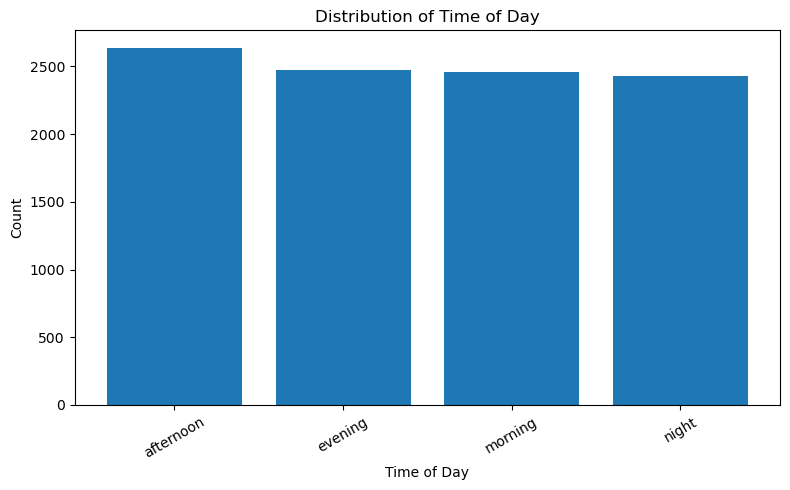

,HVAC Operation Mode,count
0,cooling_active,1502
1,maintenance_mode,1500
2,heating_active,1468
3,off,1456
4,eco_mode,1452
5,ventilation_only,1394
6,COOLING_ACTIVE,112
7,ECO_MODE,112
8,MAINTENANCE_MODE,106
9,Off,103


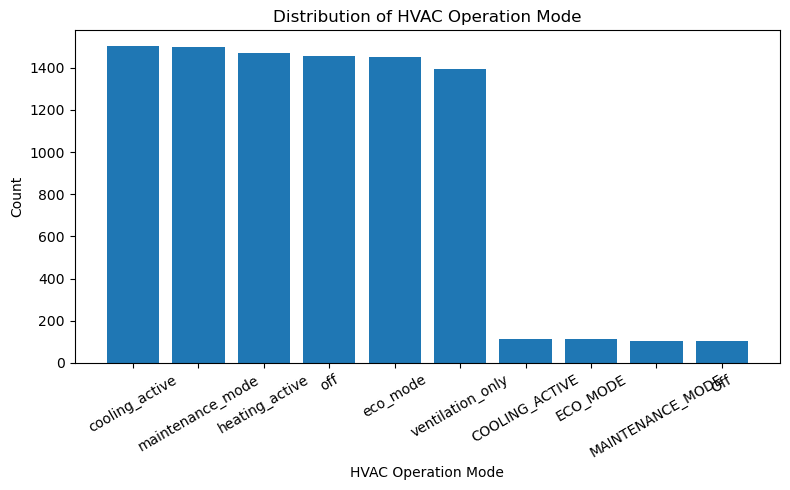

,Ambient Light Level,count
0,very_bright,3387
1,bright,2697
2,moderate,1463
3,None,1054
4,dim,864
5,very_dim,535


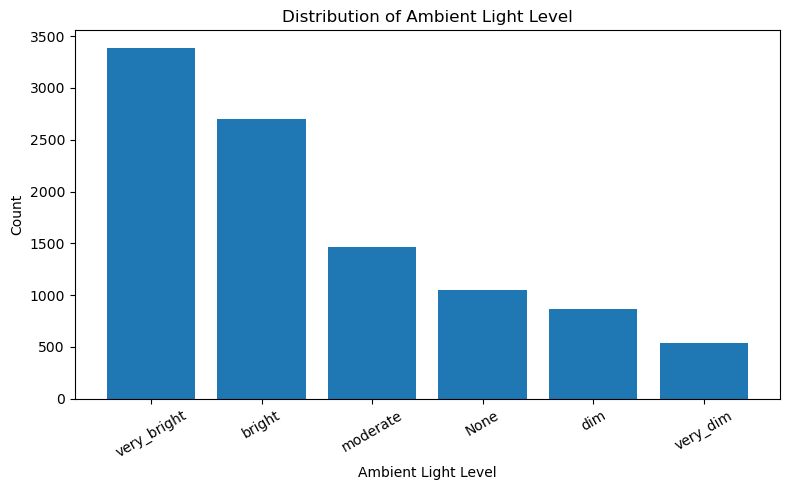

,Activity Level,count
0,Low Activity,5767
1,Moderate Activity,3138
2,High Activity,1095


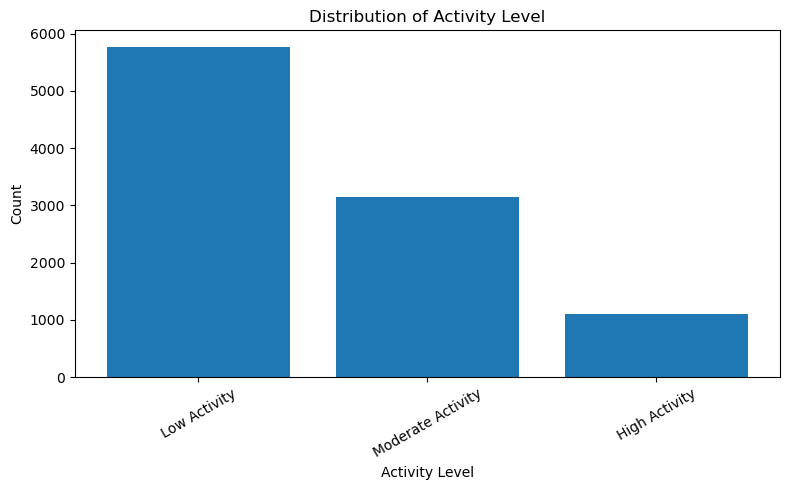

In [13]:
top_n = config.get("eda", {}).get("top_n_categories", 10)

for column in categorical_columns:
    counts = df_eda[column].value_counts(dropna=False).head(top_n).reset_index()
    counts.columns = [column, "count"]
    display(counts)
    counts.to_csv(f"results/category_distribution_{column.replace(' ', '_')}.csv", index=False)

    plt.figure(figsize=(8, 5))
    plt.bar(counts[column].astype(str), counts["count"])
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Count")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.savefig(f"visuals/category_distribution_{column.replace(' ', '_')}.png", dpi=150)
    plt.show()

## 14. Correlation Matrix

Purpose: Check how numerical sensor readings relate to each other. Highly correlated features may carry similar information.

,Temperature,Humidity,CO2_InfraredSensor,CO2_ElectroChemicalSensor,MetalOxideSensor_Unit1,MetalOxideSensor_Unit2,MetalOxideSensor_Unit3,MetalOxideSensor_Unit4,CO_GasSensor,Session ID
Temperature,1.000000,-0.004204,-0.002652,-0.008965,-0.009266,0.000989,-0.016650,-0.004252,0.012445,-0.007302
Humidity,-0.004204,1.000000,0.048803,-0.088219,-0.032126,-0.069730,-0.034095,-0.062772,0.046846,0.026031
CO2_InfraredSensor,-0.002652,0.048803,1.000000,-0.318149,-0.396787,-0.426149,-0.259237,-0.419143,0.307004,0.084400
CO2_ElectroChemicalSensor,-0.008965,-0.088219,-0.318149,1.000000,0.388427,0.652527,0.396434,0.588547,-0.466698,-0.099898
MetalOxideSensor_Unit1,-0.009266,-0.032126,-0.396787,0.388427,1.000000,0.742308,0.454482,0.771478,-0.601764,-0.095644
MetalOxideSensor_Unit2,0.000989,-0.069730,-0.426149,0.652527,0.742308,1.000000,0.612475,0.949585,-0.703496,-0.111036
MetalOxideSensor_Unit3,-0.016650,-0.034095,-0.259237,0.396434,0.454482,0.612475,1.000000,0.608960,-0.443773,-0.034502
MetalOxideSensor_Unit4,-0.004252,-0.062772,-0.419143,0.588547,0.771478,0.949585,0.608960,1.000000,-0.702439,-0.089817
CO_GasSensor,0.012445,0.046846,0.307004,-0.466698,-0.601764,-0.703496,-0.443773,-0.702439,1.000000,0.164123
Session ID,-0.007302,0.026031,0.084400,-0.099898,-0.095644,-0.111036,-0.034502,-0.089817,0.164123,1.000000


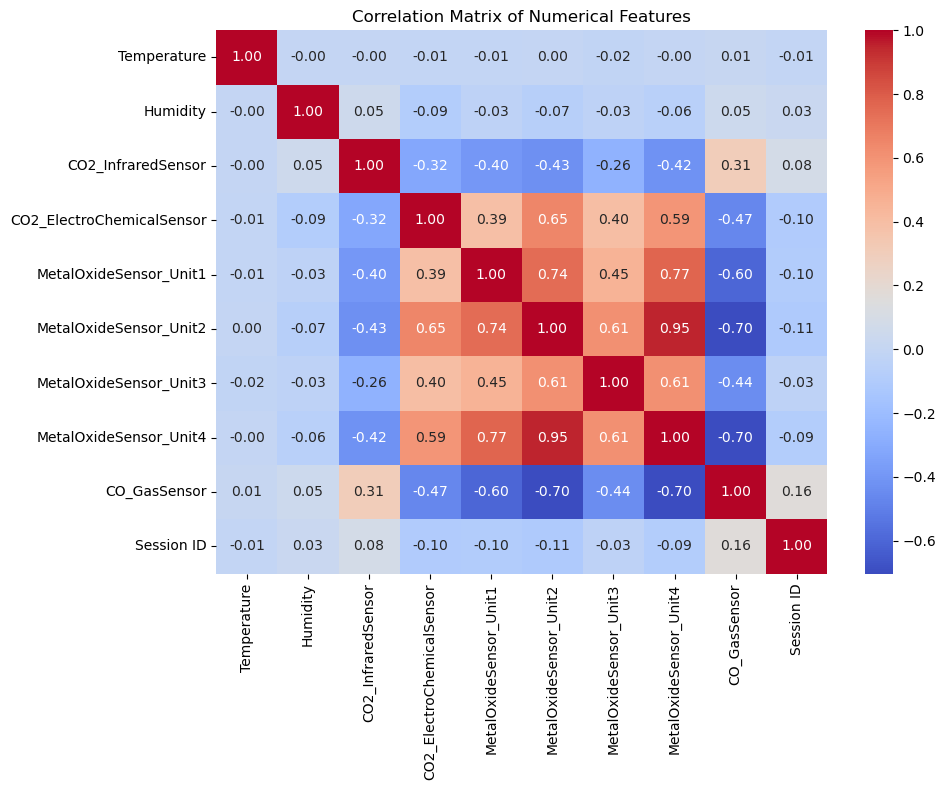

In [14]:
correlation_matrix = df_eda[numeric_columns].corr()
display(correlation_matrix)
correlation_matrix.to_csv("results/correlation_matrix.csv")

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix of Numerical Features")
plt.tight_layout()
plt.savefig("visuals/correlation_heatmap.png", dpi=150)
plt.show()

## 15. Sensor Averages by Activity Level

Purpose: Compare sensor readings across activity levels. This gives early insight into which variables may help predict the target later.

,Temperature,Humidity,CO2_InfraredSensor,CO2_ElectroChemicalSensor,MetalOxideSensor_Unit1,MetalOxideSensor_Unit2,MetalOxideSensor_Unit3,MetalOxideSensor_Unit4,CO_GasSensor,Session ID
Activity Level,,,,,,,,,,
High Activity,39.03,51.76,108.78,584.29,473.35,735.14,688.01,621.00,1.15,5434.52
Low Activity,42.73,52.09,114.80,572.04,458.44,718.15,668.53,598.00,1.50,5518.35
Moderate Activity,42.47,50.78,101.16,588.78,493.04,744.76,699.84,635.37,0.95,5259.44


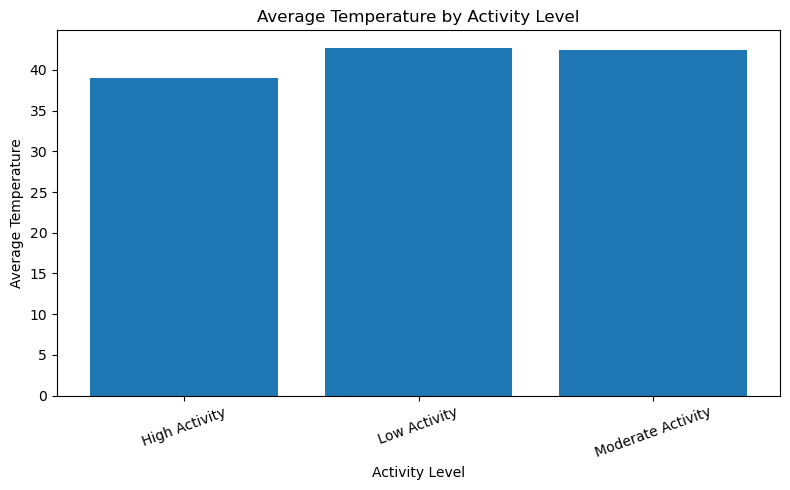

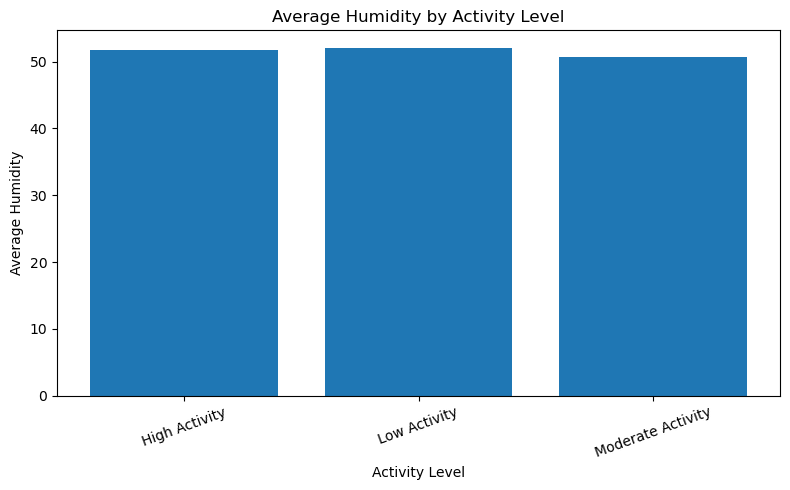

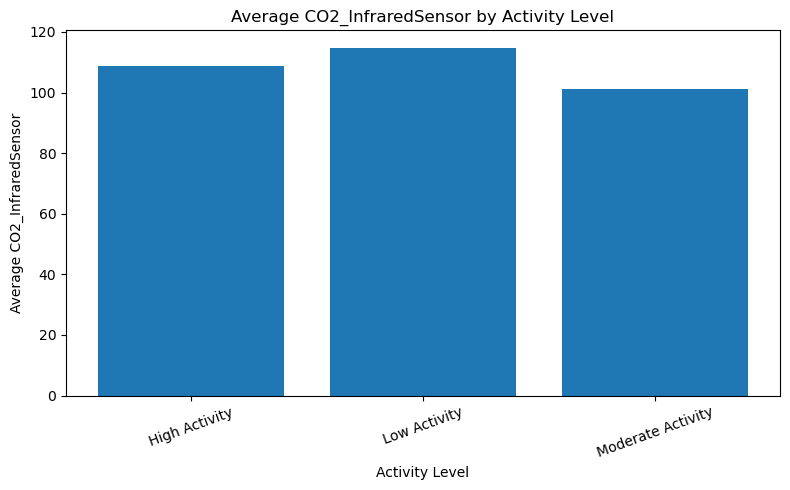

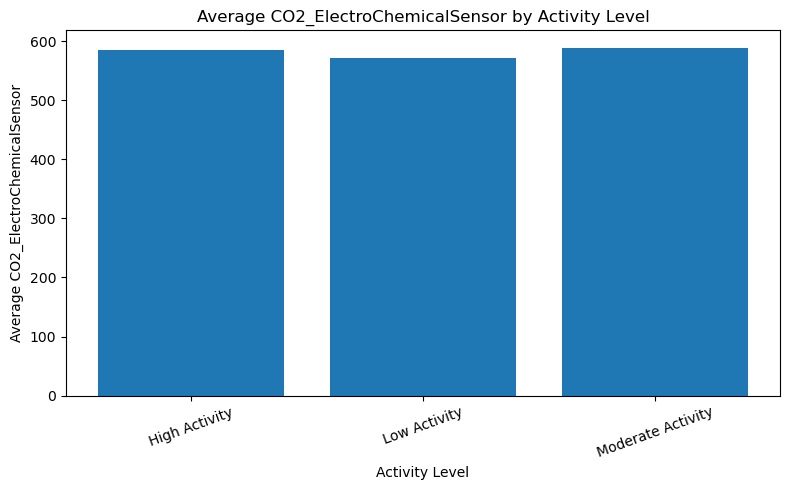

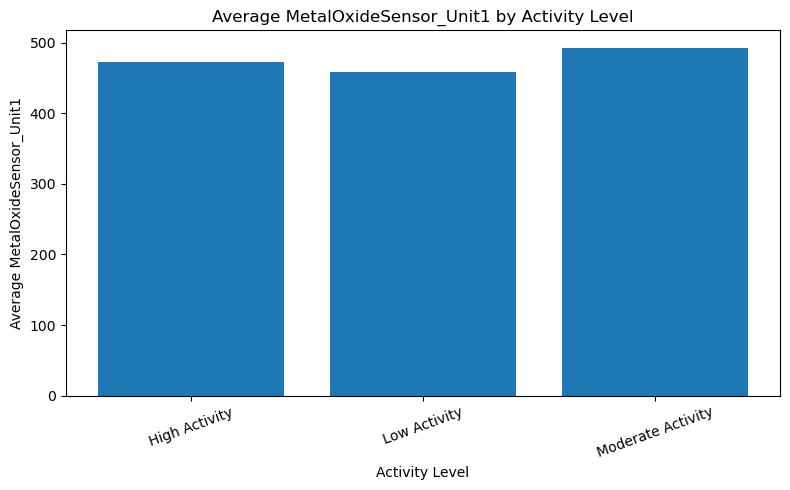

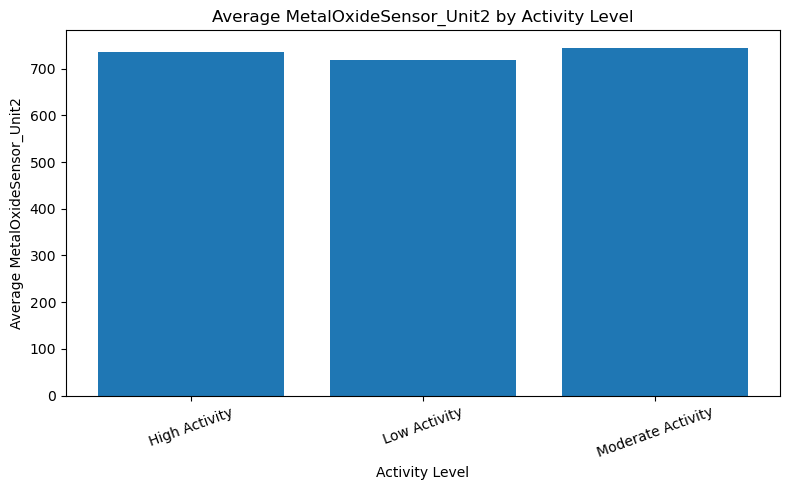

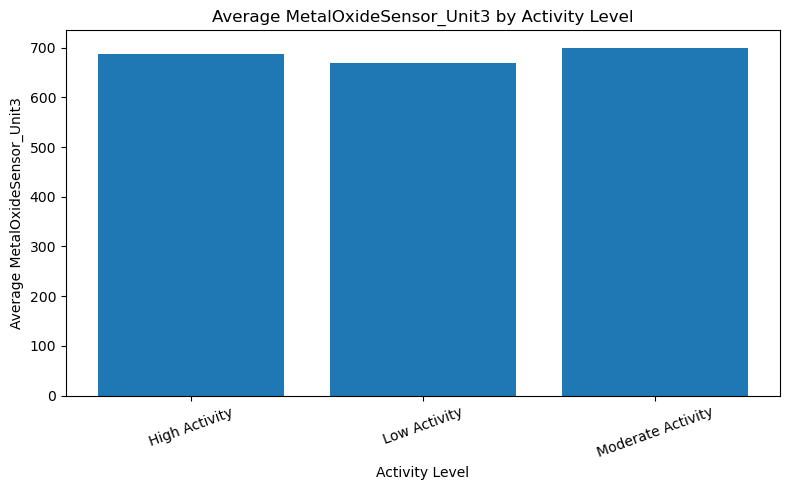

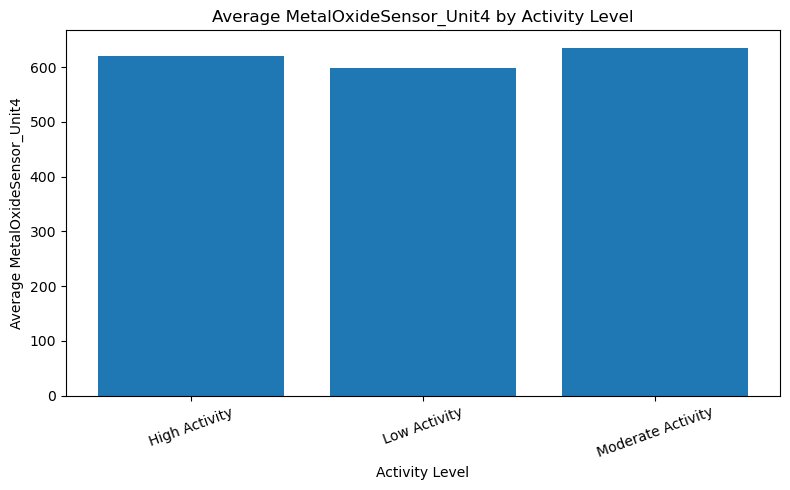

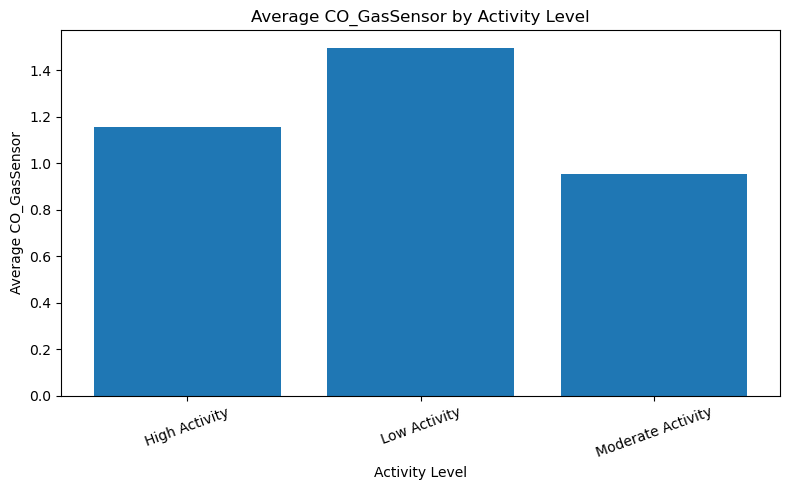

In [15]:
grouped_summary = df_eda.groupby(target_column)[numeric_columns].mean().round(2)
display(grouped_summary)
grouped_summary.to_csv("results/numerical_mean_by_activity_level.csv")

for column in numeric_columns:
    if column in drop_columns:
        continue
    avg_by_activity = df_eda.groupby(target_column)[column].mean().reset_index()
    plt.figure(figsize=(8, 5))
    plt.bar(avg_by_activity[target_column].astype(str), avg_by_activity[column])
    plt.title(f"Average {column} by Activity Level")
    plt.xlabel("Activity Level")
    plt.ylabel(f"Average {column}")
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.savefig(f"visuals/average_{column.replace(' ', '_')}_by_activity.png", dpi=150)
    plt.show()

## 16. Week 6 Final Insights

Based on this EDA:

1. The target variable is `Activity Level`, which must be cleaned because some labels may be inconsistent.
2. `Session ID` should not be treated as a predictive feature because it is an identifier, not an environmental reading.
3. Missing values exist and must be handled during Week 7 preprocessing.
4. Numerical sensor readings should be checked for outliers because the dataset may contain contaminated or synthetic values.
5. Class distribution should be considered when choosing evaluation metrics; Macro F1 is suitable if classes are imbalanced.
6. Sensor averages by activity level give early signs of which features may be useful for prediction.

## Key Patterns of Concern Identified

From the EDA, several possible patterns of concern were identified:

1. **Air quality concerns**  
   High CO2 and CO-related readings may suggest poor ventilation or unsafe indoor air conditions. These readings should be monitored because they may affect the resident's comfort and safety.

2. **Environmental comfort concerns**  
   Unusual temperature and humidity values may indicate that the living environment is too hot, too cold, too dry, or too humid. This can be useful for caregivers and facility operators when checking whether the resident's home environment is suitable.

3. **Lighting-related concerns**  
   Very dim lighting conditions may be important when combined with low activity levels. This may suggest that the resident is inactive in a poorly lit environment, which could require follow-up.

4. **Sensor reliability concerns**  
   Missing values were found in some sensor columns. Since the project depends on non-invasive monitoring, missing sensor data may reduce the reliability of future predictions. These issues should be handled before model training.

5. **Activity-level monitoring concerns**  
   The Activity Level column shows how resident activity is classified. By comparing activity levels with environmental readings, family members and healthcare providers can better understand whether low or unusual activity may be linked to indoor conditions.

## Value to Family Members and Healthcare Providers

The EDA findings can help family members and healthcare providers by highlighting situations that may require attention. For example, repeated low activity together with unusual air quality, temperature, humidity, or lighting conditions may indicate that the resident's living environment should be checked. However, these EDA findings are only early indicators and should not be treated as final medical conclusions. In Week 7, machine learning models will be trained to determine which features are most useful for predicting Activity Level.
Next step for Week 7: build a `.py` machine learning pipeline that trains, tunes, evaluates, and saves at least three models.